In [144]:
import pandas as pd
import numpy as np

In [145]:
ranks = pd.read_csv('fifa_mens_rank.csv')
ranks.info()

<class 'pandas.DataFrame'>
RangeIndex: 13130 entries, 0 to 13129
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             13130 non-null  int64  
 1   semester         13130 non-null  int64  
 2   rank             13130 non-null  int64  
 3   team             13130 non-null  str    
 4   acronym          13130 non-null  str    
 5   total.points     13130 non-null  float64
 6   previous.points  13130 non-null  float64
 7   diff.points      13130 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 820.8 KB


In [146]:
print(list(ranks.columns))

['date', 'semester', 'rank', 'team', 'acronym', 'total.points', 'previous.points', 'diff.points']


In [147]:
ranks

,date,semester,rank,team,acronym,total.points,previous.points,diff.points
0,2024,2,1,Argentina,ARG,1867.25,1883.50,-16.25
1,2024,2,2,France,FRA,1859.78,1859.85,-0.07
2,2024,2,3,Spain,ESP,1853.27,1844.33,8.94
3,2024,2,4,England,ENG,1813.81,1807.83,5.98
4,2024,2,5,Brazil,BRA,1775.85,1784.37,-8.52
...,...,...,...,...,...,...,...,...
13125,1992,2,149,Lebanon,LBN,0.00,0.00,0.00
13126,1992,2,149,Bahamas,BAH,0.00,0.00,0.00
13127,1992,2,149,Maldives,MDV,0.00,0.00,0.00
13128,1992,2,149,Rwanda,RWA,0.00,0.00,0.00


C:\Users\HomePC\AppData\Local\Temp\ipykernel_12756\1627244004.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ranks.head(20), y=ranks['total.points'].head(20), x=ranks['team'].head(20), palette='viridis')


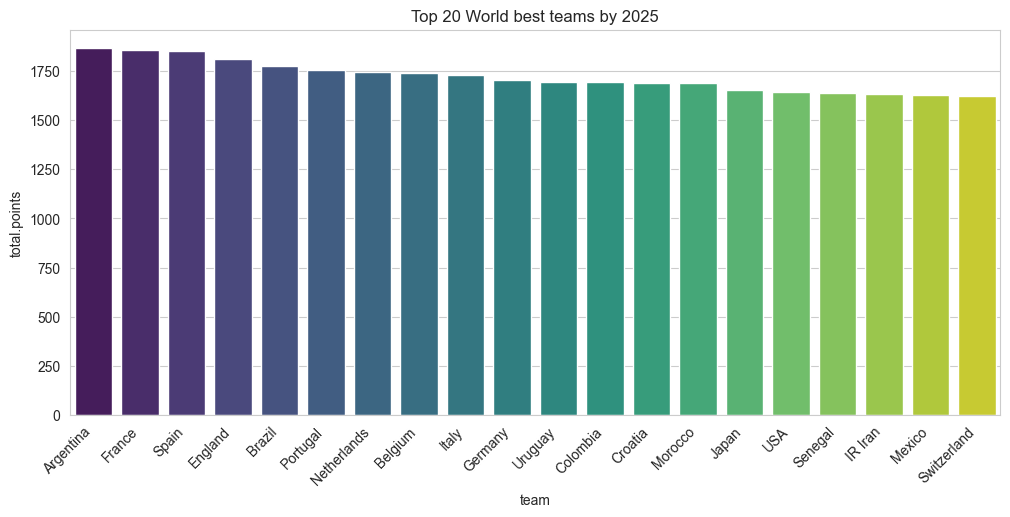

In [148]:
#viewing top 10 countries
import seaborn as sns
import matplotlib.pyplot as plt

plot = plt.figure(figsize=(12,5))
sns.barplot(ranks.head(20), y=ranks['total.points'].head(20), x=ranks['team'].head(20), palette='viridis')
plt.xticks(rotation=45, ha='right')
sns.set_style('whitegrid')
plt.title('Top 20 World best teams by 2025')
# plt.xlabel(ranks['team'].head(20), rotation=90)
plt.show()

In [149]:
#removing semester 1 in the semester columns and all of its respective data
rank22 = ranks.drop(ranks[ranks['semester'] == 1].index, inplace=True) 
ranks

,date,semester,rank,team,acronym,total.points,previous.points,diff.points
0,2024,2,1,Argentina,ARG,1867.25,1883.50,-16.25
1,2024,2,2,France,FRA,1859.78,1859.85,-0.07
2,2024,2,3,Spain,ESP,1853.27,1844.33,8.94
3,2024,2,4,England,ENG,1813.81,1807.83,5.98
4,2024,2,5,Brazil,BRA,1775.85,1784.37,-8.52
...,...,...,...,...,...,...,...,...
13125,1992,2,149,Lebanon,LBN,0.00,0.00,0.00
13126,1992,2,149,Bahamas,BAH,0.00,0.00,0.00
13127,1992,2,149,Maldives,MDV,0.00,0.00,0.00
13128,1992,2,149,Rwanda,RWA,0.00,0.00,0.00


In [150]:
ranks['date_str'] = np.where(ranks['semester'] == 2,  
                                   ranks['date'].astype(str) + '-12-31',
                                   ranks['date'].astype(str) + '-06-30')    
ranks['rank_date'] = pd.to_datetime(ranks['date_str'], errors='coerce')
ranks2 = ranks.drop(columns=['date_str'], inplace=True)

In [151]:
#raks during the years with world cups
ranks['date'] = pd.to_datetime(ranks['date'], errors='coerce', format='%Y')
ranks['year'] = ranks['date'].dt.year

In [152]:
ranks.drop(columns=['date'], inplace=True)
ranks

,semester,rank,team,acronym,total.points,previous.points,diff.points,rank_date,year
0,2,1,Argentina,ARG,1867.25,1883.50,-16.25,2024-12-31,2024
1,2,2,France,FRA,1859.78,1859.85,-0.07,2024-12-31,2024
2,2,3,Spain,ESP,1853.27,1844.33,8.94,2024-12-31,2024
3,2,4,England,ENG,1813.81,1807.83,5.98,2024-12-31,2024
4,2,5,Brazil,BRA,1775.85,1784.37,-8.52,2024-12-31,2024
...,...,...,...,...,...,...,...,...,...
13125,2,149,Lebanon,LBN,0.00,0.00,0.00,1992-12-31,1992
13126,2,149,Bahamas,BAH,0.00,0.00,0.00,1992-12-31,1992
13127,2,149,Maldives,MDV,0.00,0.00,0.00,1992-12-31,1992
13128,2,149,Rwanda,RWA,0.00,0.00,0.00,1992-12-31,1992


In [153]:
# #top 20 teams with flags
# import pycountry
# import pycountry_convert as pc
# def get_flag(country_name):
#     try:
#         country = pycountry.countries.get(name=country_name)
#         if country is None:
#             country = pycountry.countries.search_fuzzy(country_name)[0]
#         country_code = country.alpha_2
#         continent_code = pc.country_alpha2_to_continent_code(country_code)
#         flag_url = f"https://flagcdn.com/w320/{country_code.lower()}.png"
#         return flag_url
#     except Exception as e:
#         print(f"Error fetching flag for {country_name}: {e}")
#         return None
# ranks['flag_url'] = ranks['team'].apply(get_flag)
# ranks.head(20)

In [159]:
#worldcup years
years = [year for year in range(1990, 2026, 4)]
wc_ranks = ranks.loc[(ranks['year'].astype(int).isin(years)) & 
                     (ranks['rank_date'].dt.month == 12)]
wc_ranks = wc_ranks.sort_values(by=['year', 'rank'], ascending=[False, True])
wc_ranks

,semester,rank,team,acronym,total.points,previous.points,diff.points,rank_date,year
628,2,1,Brazil,BRA,1840.77,1841.30,-0.53,2022-12-31,2022
862,2,2,Argentina,ARG,1838.38,1773.88,64.50,2022-12-31,2022
863,2,3,France,FRA,1823.39,1759.78,63.61,2022-12-31,2022
864,2,4,Belgium,BEL,1781.30,1816.71,-35.41,2022-12-31,2022
865,2,5,England,ENG,1774.19,1728.47,45.72,2022-12-31,2022
...,...,...,...,...,...,...,...,...,...
12459,2,168,Equatorial Guinea,EQG,0.00,0.00,0.00,1994-12-31,1994
12460,2,168,St. Kitts and Nevis,SKN,0.00,0.00,0.00,1994-12-31,1994
12461,2,168,Macau,MAC,0.00,0.00,0.00,1994-12-31,1994
12462,2,168,Seychelles,SEY,0.00,0.00,0.00,1994-12-31,1994


In [161]:
wc_ranks.to_csv('clean_ranks.csv', index=False)
print('All done')

All done
